# Module 1.2 — Linear Algebra for Finance  
## The Geometry of Risk, Diversification, and Opportunity

If probability is the grammar of uncertainty, linear algebra is the geometry of risk.  
In quant finance, we rarely reason about a single asset in isolation. We reason about **systems**: baskets of assets, portfolios, factors, and signals. The language of systems is vectors and matrices. A portfolio is a vector of weights. A universe of returns is a matrix. Risk is a quadratic form. Diversification is a covariance matrix. And “hidden market drivers” are often eigenvectors. In this notebook, we build a practical, professional-level intuition for the linear algebra behind modern quantitative finance and show how it becomes code: portfolio optimization, PCA risk factors, dimensionality reduction, and the efficient frontier.

---

In [11]:
# need to add more mathematical description to each function
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

def annualize_return(mu_daily, trading_days=252):
    return (1 + mu_daily)**trading_days - 1

def annualize_vol(sigma_daily, trading_days=252):
    return sigma_daily * np.sqrt(trading_days)

def cov_to_corr(Sigma):
    d = np.sqrt(np.diag(Sigma))
    return Sigma / np.outer(d, d)

def portfolio_return(mu, w):
    return float(w @ mu)

def portfolio_variance(Sigma, w):
    return float(w @ Sigma @ w)

def portfolio_vol(Sigma, w):
    return np.sqrt(portfolio_variance(Sigma, w))

## 1 Vectors, matrices, and matrix operations

In finance, “**thinking like a quant**” often means compressing a complex market into a compact mathematical object. A portfolio of $n$ assets is a **vector** $w \in \mathbb{R}^n$ whose entries are weights (capital allocations). A day of returns across all assets is another vector $r_t \in \mathbb{R}^n$. Stack many days of returns and you get a **matrix** $R \in \mathbb{R}^{T \times n}$, where each row is a time step and each column is an asset. This is not aesthetic abstraction: it is operational power. With vectors and matrices, portfolio PnL becomes dot products, risk becomes quadratic forms, factor models become linear systems, and constraints become geometry. The deep lesson is that markets are not a list of prices; they are a **high-dimensional object**. Linear algebra gives you the ability to manipulate that object, project it, compress it, optimize it, and stress it. The most practical first step is mastering matrix operations as a computational habit: shape discipline, dot products, transposes, matrix multiplication, and interpreting results as economic meaning rather than just numbers.


In quant finance, nearly every object you care about becomes a vector or a matrix. A portfolio with $n$ assets is a weight vector

$
w \in \mathbb{R}^n,\quad \mathbf{1}^\top w = 1
$

(for fully invested portfolios), where $w_i$ is the fraction of capital in asset $i$. A single time step of asset returns is a vector $r_t\in\mathbb{R}^n$. If we collect $T$ observations, we obtain the returns matrix

$
R \in \mathbb{R}^{T\times n},\quad R = \begin{bmatrix} r_1^\top \\ r_2^\top \\ \vdots \\ r_T^\top\end{bmatrix}.
$

This representation is not “math decoration”—it is computational leverage. Portfolio return at time $t$ is a dot product:

$
r_{p,t} = w^\top r_t.
$

Cumulative wealth under simple compounding is

$
W_T = W_0 \prod_{t=1}^T (1+r_{p,t}).
$

Matrix operations encode economics: dot products compute exposures, matrix multiplication builds linear transformations (e.g., factor models), transposes implement inner products, and norms quantify magnitudes. For example, $ \|w\|_1 = \sum_i |w_i| $ relates to gross exposure (leverage in long-short settings), while $\|w\|_2 $ penalizes concentration in optimization. Philosophically: linear algebra forces *shape discipline*—you must be explicit about “what depends on what.” That discipline is exactly what good trading research demands.

In [21]:
# Build a returns matrix and basic operations
# Simulate T days of returns for n assets with some correlation structure
T, n = 1500, 6

# Create a random positive semi-definite covariance matrix
A = np.random.randn(n, n)
Sigma_true = (A @ A.T)  # PSD
Sigma_true = Sigma_true / np.max(np.diag(Sigma_true)) * (0.02**2)  # scale daily vols ~2%

mu_true = np.array([0.0004, 0.00035, 0.0003, 0.00045, 0.00025, 0.00038])

R = np.random.multivariate_normal(mean=mu_true, cov=Sigma_true, size=T)  # (T, n)
R = pd.DataFrame(R, columns=[f"Asset_{i+1}" for i in range(n)])

R.head(), R.shape 

# Vector of portfolio weights (sums to 1)
w = np.array([0.20, 0.15, 0.10, 0.25, 0.10, 0.20])

# Daily portfolio return series: r_p,t = r_t^T w
rp = R.values @ w

print("Portfolio mean daily return:", rp.mean())
print("Portfolio daily volatility:", rp.std(ddof=1))


# Sample mean vector: \hat{\mu} = (1/T) * sum_t r_t
mu_hat = R.mean(axis=0).values

# Sample covariance: \hat{\Sigma} = (1/(T-1)) * sum_t (r_t - \hat{\mu})(r_t - \hat{\mu})^T
Sigma_hat = R.cov().values
corr_hat = cov_to_corr(Sigma_hat)

pd.DataFrame(corr_hat, index=R.columns, columns=R.columns)

Portfolio mean daily return: 5.7311467239589596e-05
Portfolio daily volatility: 0.006900206361729183


,Asset_1,Asset_2,Asset_3,Asset_4,Asset_5,Asset_6
Asset_1,1.000000,-0.104676,0.257752,0.681636,-0.714726,0.259838
Asset_2,-0.104676,1.000000,0.142396,-0.490650,0.247604,-0.090251
Asset_3,0.257752,0.142396,1.000000,0.423626,0.290045,0.662475
Asset_4,0.681636,-0.490650,0.423626,1.000000,-0.628461,0.685767
Asset_5,-0.714726,0.247604,0.290045,-0.628461,1.000000,-0.085618
Asset_6,0.259838,-0.090251,0.662475,0.685767,-0.085618,1.000000


## 2 Eigenvalues, eigenvectors, and PCA

Correlation and covariance tell us that assets move together, but they do not tell us **how** that co-movement is organized. Eigenvalues and eigenvectors answer that question by revealing the “principal directions” of variation in a covariance (or correlation) matrix. In finance, those directions often correspond to interpretable economic forces: a broad market factor, sector rotations, macro shocks, or liquidity regimes. Technically, if $\Sigma$ is a covariance matrix, eigenvectors $v_i$ satisfy $\Sigma v_i = \lambda_i v_i$. The eigenvalue $\lambda_i$ measures how much variance is explained in that direction. PCA (Principal Component Analysis) uses this decomposition to rotate the coordinate system so that the first few axes capture most of the action. This is not just statistics—it is risk insight. A portfolio can be diversified across assets but still concentrated in a hidden factor if its weights align with a dominant eigenvector. Practitioners use PCA to build factor models, reduce dimensionality, stabilize noisy covariance estimates, and detect regime shifts when the leading eigenvalue spikes. Philosophically, eigenvectors remind us: markets have structure, but it is often invisible until you choose the right basis to see it.




Covariance tells us assets co-move, but eigen-decomposition tells us the *directions* of co-movement. For a symmetric covariance matrix

$
\Sigma \in \mathbb{R}^{n\times n},\quad \Sigma=\Sigma^\top,\quad \Sigma\succeq 0,
$

there exists an orthonormal basis of eigenvectors $V=[v_1,\dots,v_n]$ and nonnegative eigenvalues $\lambda_1\ge\lambda_2\ge\dots\ge 0$ such that

$
\Sigma v_i = \lambda_i v_i,\qquad
\Sigma = V \Lambda V^\top,\quad \Lambda=\mathrm{diag}(\lambda_1,\dots,\lambda_n),\quad V^\top V = I.
$

Interpretation: $v_i$ is a “principal risk direction,” and $\lambda_i$ is the variance carried in that direction. The total variance is $\mathrm{tr}(\Sigma)=\sum_i \lambda_i$. The fraction explained by the first $k$ components is

$
\frac{\sum_{i=1}^k \lambda_i}{\sum_{i=1}^n \lambda_i}.
$

PCA rotates data into this eigen-basis. For centered returns $X = R - \mathbf{1}\hat{\mu}^\top$, the $k$-dimensional factor time series (principal components) is

$
F_k = X V_k \in \mathbb{R}^{T\times k},
$

where $V_k=[v_1,\dots,v_k]$. In finance, $v_1$ often resembles a market mode (many assets move together), while later components resemble sector/style rotations. A portfolio can be diversified across names but still concentrated along a dominant eigenvector—this is “hidden factor concentration.” Philosophically: eigenvectors teach that *risk is directional*, not merely scalar.


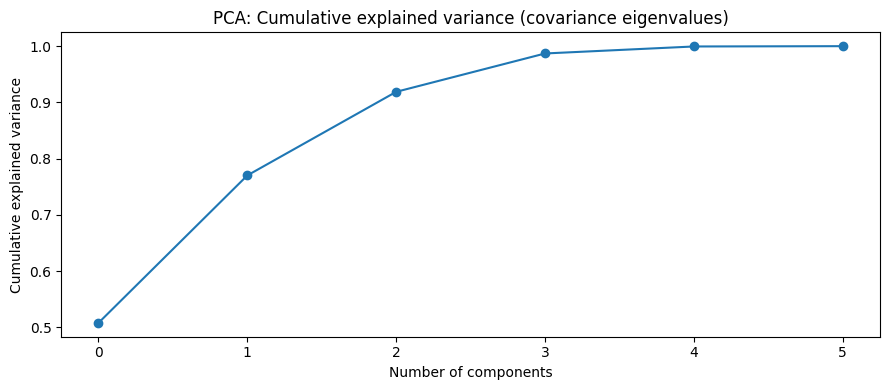

In [23]:
# Eigen-decomposition of covariance and PCA explained variance
# Eigen-decomposition of sample covariance
eigvals, eigvecs = np.linalg.eigh(Sigma_hat)  # eigh for symmetric matrices
# Sort descending
idx = np.argsort(eigvals)[::-1]
eigvals = eigvals[idx]
eigvecs = eigvecs[:, idx]

explained = eigvals / eigvals.sum()
cum_explained = np.cumsum(explained)

pd.DataFrame({
    "eigenvalue": eigvals,
    "explained_var_ratio": explained,
    "cum_explained": cum_explained
})

# PC time series and factor exposures
X = R.values - R.values.mean(axis=0, keepdims=True)

k = 3
F = X @ eigvecs[:, :k]  # principal component factors

factor_df = pd.DataFrame(F, columns=[f"PC{i+1}" for i in range(k)])
factor_df.head()

plt.figure(figsize=(9,4))
plt.plot(cum_explained, marker="o")
plt.title("PCA: Cumulative explained variance (covariance eigenvalues)")
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.tight_layout()
plt.show()

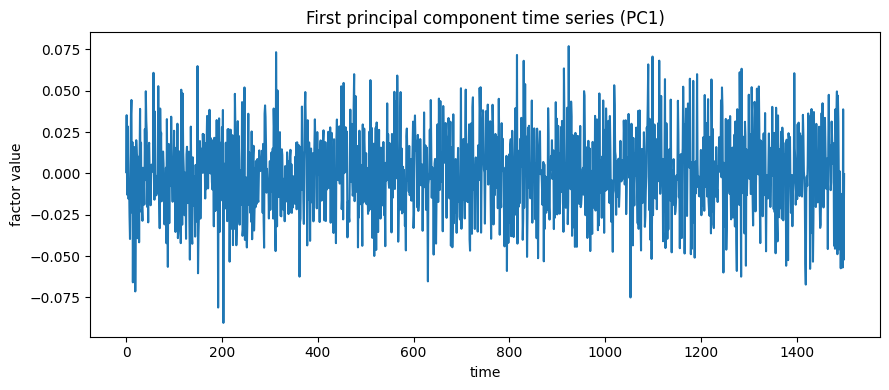

PC1   -0.140162
PC2    0.306145
Name: Portfolio exposure, dtype: float64

In [24]:
# PCA factor returns (principal component time series)
# Center returns
X = R.values - R.values.mean(axis=0, keepdims=True)

# Principal component time series: factor_t = X_t @ v_k
k = 2
factors = X @ eigvecs[:, :k]  # (T, k)

factor_df = pd.DataFrame(factors, columns=[f"PC{i+1}" for i in range(k)])
factor_df.head()

plt.figure(figsize=(9,4))
plt.plot(factor_df["PC1"].values)
plt.title("First principal component time series (PC1)")
plt.xlabel("time")
plt.ylabel("factor value")
plt.tight_layout()
plt.show()


# Portfolio exposure to PCs: a_k = w^T v_k
exposure = w @ eigvecs[:, :k]
pd.Series(exposure, index=[f"PC{i+1}" for i in range(k)], name="Portfolio exposure")

## 3 Optimization and quadratic forms

Portfolio risk is inherently quadratic. The variance of a portfolio with weights $w$ and covariance matrix $\Sigma$ is $w^\top \Sigma w$. This expression is a **quadratic form**, and it is the mathematical engine behind modern portfolio theory. Why quadratic? Because variance depends on pairwise interactions: each weight couples with every other through covariance. This coupling is what makes diversification possible and also what makes risk hard to reason about by intuition alone. Optimization enters because real portfolios are decisions under constraints: limited leverage, long-only rules, turnover costs, risk budgets, or neutrality constraints. The canonical problem—minimize variance for a target return—is a convex quadratic program when $\Sigma$ is positive semidefinite. That convexity is not a technical detail; it is a guarantee that the geometry of the problem is well-behaved and that “best” really means best. Philosophically, quadratic forms teach a mature lesson: risk is not additive. You cannot understand portfolio risk by summing individual risks. Risk is relational; it lives in the off-diagonal terms. To be a good trader or portfolio builder, you must learn to see those relationships as first-class citizens.



Portfolio variance is a quadratic form. For weights $w$ and covariance $\Sigma$,

$
\mathrm{Var}(r_p) = \mathrm{Var}(w^\top r) = w^\top \Sigma w.
$

This expands as

$
w^\top \Sigma w = \sum_{i=1}^n \sum_{j=1}^n w_i w_j \Sigma_{ij},
$

making explicit that risk is relational: every pair $(i,j)$ contributes through covariance. Because $\Sigma\succeq 0$, this quadratic form is convex in $w$, which is why many portfolio problems are tractable.

Quadratic forms also define *ellipsoids* in weight space:

$
\{w: w^\top \Sigma w \le c\}
$

is a risk-budget set. Optimization is the act of choosing a point in feasible space that best satisfies an objective under constraints. Canonical Markowitz optimization (minimum variance at target return) is

$
\min_w \; w^\top \Sigma w
\quad \text{s.t.}\quad
\mathbf{1}^\top w = 1,\;\; \mu^\top w = r_\text{target},\;\; w \ge 0 \;(\text{optional}).
$

From a professional perspective, optimization is a magnifier: errors in $\hat{\mu}$ and $\hat{\Sigma}$ get amplified into extreme weights. Thus constraints, regularization, and robust estimation are not “practical hacks”—they are mathematically motivated stabilizers. Philosophically: optimization forces you to write down what you believe and then confront the consequences.

In [25]:
# Risk as a quadratic form + contribution intuition
# Portfolio variance from quadratic form
var_p = portfolio_variance(Sigma_hat, w)
vol_p = np.sqrt(var_p)

print("Portfolio daily variance:", var_p)
print("Portfolio daily volatility:", vol_p)

# Marginal contribution to risk: Sigma w (not normalized)
marginal = Sigma_hat @ w  # ∂(w^T Σ w)/∂w = 2 Σ w (up to factor 2)
# Component contribution to variance: w_i * (Sigma w)_i
component_var = w * marginal
pd.DataFrame({
    "weight": w,
    "marginal_risk": marginal,
    "component_var_contrib": component_var
}, index=R.columns)



Portfolio daily variance: 4.7612847834447875e-05
Portfolio daily volatility: 0.006900206361729182


,weight,marginal_risk,component_var_contrib
Asset_1,0.20,0.000063,0.000013
Asset_2,0.15,0.000011,0.000002
Asset_3,0.10,0.000056,0.000006
Asset_4,0.25,0.000047,0.000012
Asset_5,0.10,-0.000024,-0.000002
Asset_6,0.20,0.000091,0.000018


## 4 Covariance matrices in portfolio theory

The covariance matrix $\Sigma$ is the single most important object in classical portfolio theory. It encodes not only how risky each asset is (diagonal entries), but how risks interact (off-diagonals). A portfolio’s volatility depends more on covariance structure than on individual volatilities, especially in multi-asset portfolios. In calm regimes, correlations may appear stable and diversification seems easy. In stress regimes, correlations often rise and diversification “disappears,” not because the math broke, but because the world changed. Covariance estimation is also noisy: with finite samples, $\hat{\Sigma}$ contains error, and that error can dominate optimization results. This is why professionals use shrinkage, factor models, rolling windows, and robust techniques. Covariance matrices are not just statistics; they are assumptions about how the future couples assets together. In quant finance, your portfolio is only as honest as your covariance model. Philosophically, $\Sigma$ represents a belief about interdependence—and markets repeatedly teach that interdependence is dynamic, regime-dependent, and occasionally brutal.



The covariance matrix

$
\Sigma = \mathbb{E}\left[(r-\mu)(r-\mu)^\top\right]
$

is the central object of portfolio risk. Diagonal entries $\Sigma_{ii}$ are individual variances, while off-diagonals $\Sigma_{ij}$ encode co-movement. Correlation is the normalized version:

$
\rho_{ij} = \frac{\Sigma_{ij}}{\sqrt{\Sigma_{ii}\Sigma_{jj}}}.
$

Portfolio volatility is determined less by the diagonals than by the *structure* of off-diagonals—especially in diversified portfolios. A key phenomenon in markets is *correlation tightening*: during stress, many assets become more correlated, so diversification benefits shrink exactly when needed most. This is not a flaw of theory; it is a feature of the world.

Estimation matters. With finite samples, $\hat{\Sigma}$ is noisy, and the noise worsens as $n/T$ grows. For professionals, this motivates shrinkage and factor models:

$
\Sigma \approx B \Sigma_f B^\top + D,
$

where $B$ are factor loadings, $\Sigma_f$ factor covariance, and $D$ idiosyncratic risk (often diagonal). Philosophically: $\Sigma$ is not just a statistic; it is your encoded belief about interdependence in the future, and markets punish stale beliefs.

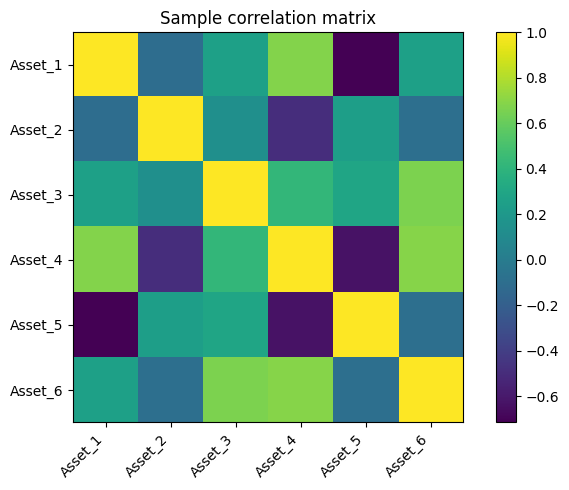

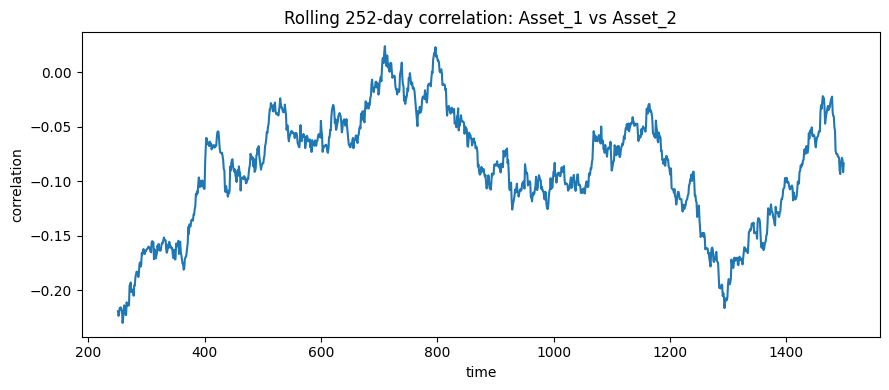

In [26]:
# Visualize correlation matrix (heatmap)  + rolling correlation intuition
corr = pd.DataFrame(corr_hat, index=R.columns, columns=R.columns)

plt.figure(figsize=(7,5))
plt.imshow(corr.values)
plt.title("Sample correlation matrix")
plt.xticks(range(n), R.columns, rotation=45, ha="right")
plt.yticks(range(n), R.columns)
plt.colorbar()
plt.tight_layout()
plt.show()


# Rolling correlation example (Asset_1 vs Asset_2)
roll = 252
rolling_corr = R["Asset_1"].rolling(roll).corr(R["Asset_2"])

plt.figure(figsize=(9,4))
plt.plot(rolling_corr.values)
plt.title(f"Rolling {roll}-day correlation: Asset_1 vs Asset_2")
plt.xlabel("time")
plt.ylabel("correlation")
plt.tight_layout()
plt.show()

## 5 Portfolio optimization using matrix algebra (Markowitz, long-only)

Markowitz portfolio theory formalizes a professional intuition: you should not chase return without pricing the risk you must endure to obtain it. Mathematically, the efficient frontier is the set of portfolios that minimize variance for a given expected return (or maximize return for a given variance). In its cleanest form, the problem is: minimize $w^\top \Sigma w$ subject to $w^\top \mu = r$ and $1^\top w = 1$, optionally with constraints like $w \ge 0$ for long-only portfolios. This is not only an optimization routine; it is a disciplined way of converting beliefs $(\mu, \Sigma)$ into decisions $w$. The practitioner’s warning is that optimization is a magnifier: it amplifies estimation errors in $\mu$ and $\Sigma$. The professional’s response is to impose constraints, use robust estimates, and treat optimized portfolios as hypotheses—tested, stress-tested, and updated. Philosophically, portfolio optimization is where mathematics meets humility: it forces you to state your assumptions explicitly, then live with the consequences of those assumptions in PnL space.



The efficient frontier is the set of Pareto-optimal portfolios in the risk-return plane. Using estimates $\hat{\mu}$ and $\hat{\Sigma}$, each portfolio $w$ maps to:

$
\text{return: } \hat{\mu}^\top w,\qquad
\text{variance: } w^\top \hat{\Sigma} w.
$

The frontier solves the constrained family:

$
\min_w\; w^\top \hat{\Sigma} w
\quad\text{s.t.}\quad \mathbf{1}^\top w=1,\;\; \hat{\mu}^\top w=r,\;\; w\in\mathcal{W},
$

where $\mathcal{W}$ encodes practical constraints (e.g., long-only $w\ge 0$, leverage bounds, sector caps). The frontier is not “the truth”; it is the geometric boundary induced by your modeling assumptions. Changing $\mathcal{W}$, shrinkage, or estimation window changes the geometry and thus the frontier.

For teaching without external solvers, we approximate the frontier by sampling many feasible portfolios $w$ from the simplex. The boundary of minimum variance at each return level approximates the frontier and builds intuition. In professional systems, you would solve convex programs (e.g., via CVXPY) and include transaction costs and robust estimators—but the geometry remains the same.

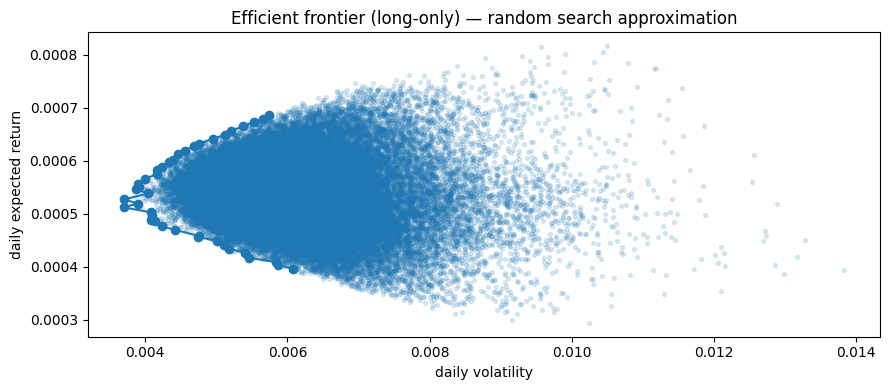

Asset_1    0.338050
Asset_2    0.008181
Asset_3    0.245028
Asset_4    0.027993
Asset_5    0.089684
Asset_6    0.291064
Name: w* (approx max Sharpe on frontier), dtype: float64

In [17]:
# Efficient frontier (long-only) via simple constrained search
# Estimate mu and Sigma from simulated data
mu = mu_hat
Sigma = Sigma_hat

def random_simplex(n, m):
    """m samples from simplex: w>=0, sum w=1"""
    x = np.random.rand(m, n)
    x = x / x.sum(axis=1, keepdims=True)
    return x

m = 60000
W = random_simplex(n, m)

# Compute portfolio returns and vols
port_rets = W @ mu
port_vars = np.einsum('ij,jk,ik->i', W, Sigma, W)  # w^T Sigma w for each row
port_vols = np.sqrt(port_vars)

# Efficient frontier approximation: for each return bucket, keep min vol
bins = 40
ret_min, ret_max = np.quantile(port_rets, 0.01), np.quantile(port_rets, 0.99)
edges = np.linspace(ret_min, ret_max, bins+1)

frontier = []
for i in range(bins):
    mask = (port_rets >= edges[i]) & (port_rets < edges[i+1])
    if mask.sum() < 50:
        continue
    j = np.argmin(port_vols[mask])
    idx_j = np.where(mask)[0][j]
    frontier.append((port_rets[idx_j], port_vols[idx_j], W[idx_j]))

frontier_rets = np.array([x[0] for x in frontier])
frontier_vols = np.array([x[1] for x in frontier])

plt.figure(figsize=(9,4))
plt.scatter(port_vols, port_rets, alpha=0.15, s=8)
plt.plot(frontier_vols, frontier_rets, marker="o")
plt.title("Efficient frontier (long-only) — random search approximation")
plt.xlabel("daily volatility")
plt.ylabel("daily expected return")
plt.tight_layout()
plt.show()

best_idx = np.argmax(frontier_rets / frontier_vols)  # max Sharpe with rf~0 (approx)
w_star = frontier[best_idx][2]
pd.Series(w_star, index=R.columns, name="w* (approx max Sharpe on frontier)")

## 6 Principal Component Analysis for risk factors

PCA provides a principled way to discover “latent factors” that explain co-movements. In equities, the first component often resembles a market mode: many assets rising and falling together. Subsequent components can resemble sector rotations or style tilts. For a practitioner, PCA is useful because it reduces noise and reveals concentration. A portfolio can be diversified across names yet still be highly exposed to a dominant factor if its weight vector aligns with the first eigenvector of $\Sigma$. For a professional, PCA is also a diagnostic tool: when the leading eigenvalue grows, the market is becoming more one-dimensional, which often happens in crises. In risk management, PCA can be used to build factor stress tests: “What happens if PC1 drops 3 standard deviations?” Philosophically, PCA is an antidote to superficial diversification. It teaches that risk is not just about how many assets you hold; it is about which directions in market space you are truly exposed to.


Given eigen-decomposition $\Sigma = V\Lambda V^\top$, the principal components define an orthonormal change of basis. If we project centered returns $X$ onto the first $k$ eigenvectors:

$
F_k = X V_k,
$

then the covariance of $F_k$ is approximately diagonal with entries $\lambda_1,\dots,\lambda_k$, meaning components are uncorrelated and ordered by risk contribution. This is why PCA is used to create risk factors and reduce the dimensionality of a multivariate system while retaining most variance.

For trading signals, consider feature matrix $S\in\mathbb{R}^{T\times p}$. High dimensionality often implies redundancy and collinearity. PCA finds directions $u_i$ maximizing projected variance:

$
u_1 = \arg\max_{\|u\|_2=1}\mathrm{Var}(Su),
$

with subsequent components orthogonal to prior ones. The reduced representation $Z = S U_k$ preserves maximal variance among $k$-dimensional linear projections. Professionals do this not to magically create alpha, but to reduce noise, stabilize models, and prevent overfitting by controlling degrees of freedom.

In [18]:
# Factor loadings and portfolio exposure to PCs
# PC loadings (eigenvectors): columns are PCs, rows are assets
loadings = pd.DataFrame(eigvecs[:, :3], index=R.columns, columns=["PC1", "PC2", "PC3"])
loadings

# Portfolio exposure to principal components: exposure_k = w^T v_k
exposure = w @ eigvecs[:, :3]
pd.Series(exposure, index=["PC1", "PC2", "PC3"], name="Portfolio exposure to PCs")


# Portfolio exposure to principal components: exposure_k = w^T v_k
exposure = w @ eigvecs[:, :3]
pd.Series(exposure, index=["PC1", "PC2", "PC3"], name="Portfolio exposure to PCs")

PC1    0.046888
PC2   -0.110376
PC3   -0.012235
Name: Portfolio exposure to PCs, dtype: float64

## 7 Dimensionality reduction for trading signals

Trading signals are often high-dimensional: many indicators across many assets, time scales, and transforms. High dimensionality is a double-edged sword. It can capture richness, but it also invites overfitting, collinearity, and instability. Dimensionality reduction—especially linear methods like PCA—helps you compress a noisy feature space into a smaller set of orthogonal components that capture most of the variance. Practically, this can stabilize downstream models (regression, classification, portfolio construction) by reducing redundancy. Professionally, dimensionality reduction is not a guarantee of alpha; it is a risk-control technique. It helps ensure that your model is not “learning the same signal 20 times” through correlated features. Philosophically, dimensionality reduction is about focus: extracting essence from clutter. In markets, as in life, too many degrees of freedom often means too many ways to fool yourself. A smaller, well-chosen representation can be both more robust and more interpretable.

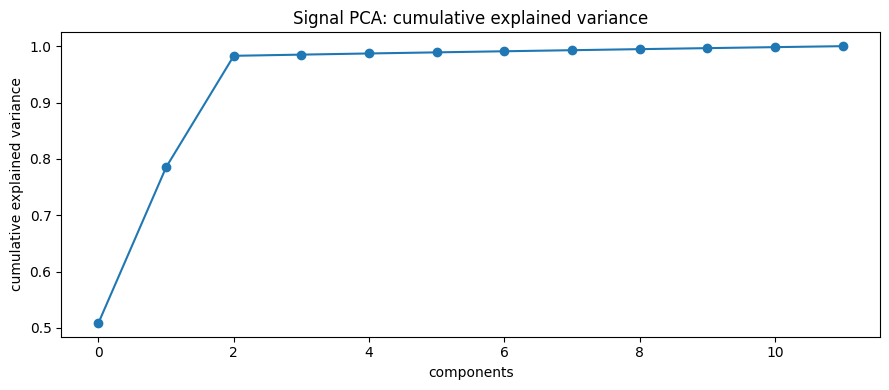

(1500, 3)

In [19]:
# Create synthetic signals and compress with PCA
# Synthetic "signal" matrix: T x p features with redundancy
T = 1500
p = 12

# Create 3 latent drivers + noise, then mix them into p features
latent = np.random.randn(T, 3)
mix = np.random.randn(3, p)
signals = latent @ mix + 0.3*np.random.randn(T, p)

# PCA via eigen-decomposition of feature covariance
S = np.cov(signals, rowvar=False)
evals_s, evecs_s = np.linalg.eigh(S)
idx = np.argsort(evals_s)[::-1]
evals_s, evecs_s = evals_s[idx], evecs_s[:, idx]

expl = evals_s / evals_s.sum()
plt.figure(figsize=(9,4))
plt.plot(np.cumsum(expl), marker="o")
plt.title("Signal PCA: cumulative explained variance")
plt.xlabel("components")
plt.ylabel("cumulative explained variance")
plt.tight_layout()
plt.show()

# Project signals onto first k components
k = 3
signals_centered = signals - signals.mean(axis=0, keepdims=True)
signals_reduced = signals_centered @ evecs_s[:, :k]  # T x k
signals_reduced.shape

## 8 Implementing efficient frontier calculations (explicit workflow)

The efficient frontier is not a single formula; it is a workflow: estimate $\mu$ and $\Sigma$, define constraints, sweep target returns, solve a variance-minimization problem for each target, then visualize the risk-return tradeoff. In production, you would solve a convex optimization problem (often with `cvxpy`), incorporate transaction costs, impose exposure limits, and use robust covariance estimates. For teaching, it is valuable to implement the frontier as an explicit calculation so the geometry becomes intuitive: the frontier is the boundary of feasible portfolios. Each point is a set of weights $w$. When you plot volatility vs expected return, you are plotting the consequences of your beliefs. The frontier teaches a philosophical truth: there is no free lunch. You can move along the curve by accepting different forms of risk, but you cannot step outside it without changing assumptions or constraints. That is why professionals spend so much time validating assumptions—because the frontier is only as real as the model behind it.

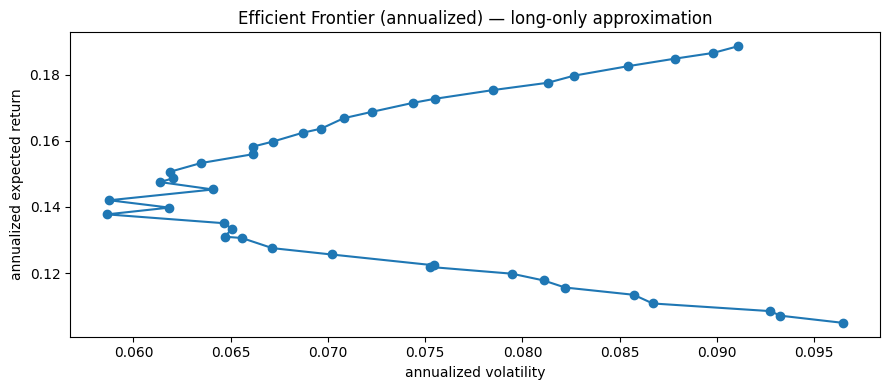

In [20]:
# Annualized and plot frontier
# Convert frontier to annualized figures (approx)
front_ret_ann = np.array([annualize_return(r) for r in frontier_rets])
front_vol_ann = np.array([annualize_vol(v) for v in frontier_vols])

plt.figure(figsize=(9,4))
plt.plot(front_vol_ann, front_ret_ann, marker="o")
plt.title("Efficient Frontier (annualized) — long-only approximation")
plt.xlabel("annualized volatility")
plt.ylabel("annualized expected return")
plt.tight_layout()
plt.show()

# Closing Reflection

Linear algebra turns “many assets” into a single object you can reason about.  
- Vectors represent positions and signals.  
- Matrices represent histories and relationships.  
- Eigenvectors reveal hidden risk directions.  
- Quadratic forms measure portfolio fragility.  
- Optimization turns beliefs into decisions.

A good trader respects uncertainty.  
A good quant respects geometry.

In the next module, we connect these tools to calculus and optimization more broadly, and we start treating trading and portfolio design as controlled decision-making under constraints.